# 项目一：逻辑回归风险基线

目标：建立第一个完整的风险识别模型，并在验证集上评估它对高风险学生的识别能力。

本节的逻辑回归是基线模型：它简单、训练快、可解释。之后的树模型和 XGBoost 都要和这个基线进行公平比较。

## 本节指标

高风险学生的标签为 1。

- Recall：真实高风险学生中，模型识别出了多少；漏报代价高时重点关注。
- Precision：模型发出风险提示的学生中，真正高风险的比例。
- F1：Precision 与 Recall 的综合。
- ROC-AUC：模型对高风险学生的排序能力，和固定阈值无关。


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
data_path = Path('projects/01_student_risk_prediction/data/raw/student-mat.csv')
if not data_path.exists():
    data_path = Path.home() / 'solo_work/算法工程师/projects/01_student_risk_prediction/data/raw/student-mat.csv'

df = pd.read_csv(data_path, sep=';')
y = (df['G3'] < 10).astype(int)
X = df.drop(columns=['G1', 'G2', 'G3'])

X_develop, X_test, y_develop, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_develop, y_develop, test_size=0.25, random_state=42, stratify=y_develop
)

In [3]:
numeric_features = X_train.select_dtypes(include='number').columns.tolist()
categorical_features = X_train.select_dtypes(exclude='number').columns.tolist()

preprocessor = ColumnTransformer([
    ('numeric', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), numeric_features),
    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), categorical_features),
])

risk_model = Pipeline([
    # Pipeline 会先在 X_train 学习预处理规则，再训练逻辑回归。
    ('preprocessor', preprocessor),
    # max_iter 增大以保证优化有足够迭代次数收敛；random_state 便于复现。
    ('classifier', LogisticRegression(max_iter=1000, random_state=42)),
])

In [4]:
# 仅用训练集拟合完整流程。
risk_model.fit(X_train, y_train)

# 在验证集上获得类别预测和“高风险概率”。
y_val_pred = risk_model.predict(X_val)
y_val_proba = risk_model.predict_proba(X_val)[:, 1]

metrics = pd.Series({
    'accuracy': accuracy_score(y_val, y_val_pred),
    'precision_at_risk': precision_score(y_val, y_val_pred),
    'recall_at_risk': recall_score(y_val, y_val_pred),
    'f1_at_risk': f1_score(y_val, y_val_pred),
    'roc_auc': roc_auc_score(y_val, y_val_proba),
}).round(3)
display(metrics.to_frame('validation score'))

print('验证集分类报告：')
print(classification_report(y_val, y_val_pred, target_names=['not at risk', 'at risk']))

,validation score
accuracy,0.658
precision_at_risk,0.483
recall_at_risk,0.538
f1_at_risk,0.509
roc_auc,0.718


验证集分类报告：
              precision    recall  f1-score   support

 not at risk       0.76      0.72      0.74        53
     at risk       0.48      0.54      0.51        26

    accuracy                           0.66        79
   macro avg       0.62      0.63      0.62        79
weighted avg       0.67      0.66      0.66        79



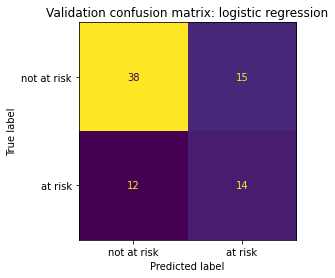

In [5]:
# 混淆矩阵对应当前默认阈值 0.5 下的具体误报和漏报数量。
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred, display_labels=['not at risk', 'at risk'], colorbar=False
)
plt.title('Validation confusion matrix: logistic regression')
plt.show()

## 当前结论

这是默认阈值 0.5 下的基线结果。下一节将不改动模型参数，而是先观察不同阈值怎样改变漏报与误报的取舍；之后再公平比较随机森林和 XGBoost。

测试集仍未使用。